# LLM Polarization Analysis

This notebook demonstrates how to use the refactored utilities for:
1. Running politician-based prompt analysis
2. Running ideology-based prompt analysis
3. Experimenting with different prompt templates
4. Comparing results with ANES survey data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# Import utilities
from config import TOPICS, DEFAULT_MODEL_PATH, DEFAULT_BATCH_SIZE
from model_utils import load_model, extract_heads_batched
from metrics_utils import compute_all_head_metrics, summarize_metrics, add_derived_metrics
from prompt_utils import (
    create_politician_prompt_set,
    create_ideology_prompt_set,
    POLITICIAN_TEMPLATES,
    IDEOLOGY_TEMPLATES,
)
from pipeline import run_politician_pipeline, run_ideology_pipeline

/project/jevans/maxzhuyt/honest_llama_env/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/project/jevans/maxzhuyt/honest_llama_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

Adjust these settings as needed:

In [2]:
# Model settings
MODEL_PATH = DEFAULT_MODEL_PATH
BATCH_SIZE = 128

# For ideology prompts: number of samples per ideology level
N_PER_LEVEL = 10

# Optional: Select subset of topics for faster testing
# TOPICS_SUBSET = {k: v for k, v in list(TOPICS.items())[:5]}
TOPICS_SUBSET = TOPICS  # Use all topics

## 2. Load Model

In [3]:
#model, tokenizer = load_model(MODEL_PATH)

## 3. Run Politician Prompt Analysis

This uses actual U.S. politician names from the NOMINATE dataset.

In [4]:
df_politician = run_politician_pipeline(
    model, tokenizer,
    topics=TOPICS_SUBSET,
    batch_size=BATCH_SIZE
)

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df_politician.to_pickle(f"df_llm_politician_{timestamp}.pkl")
print(f"Politician results shape: {df_politician.shape}")

NameError: name 'model' is not defined

## 4. Run Ideology Prompt Analysis

This uses generic ideological labels (extremely liberal -> extremely conservative).

In [ ]:
df_ideology = run_ideology_pipeline(
    model, tokenizer,
    topics=TOPICS_SUBSET,
    batch_size=BATCH_SIZE,
    n_per_level=N_PER_LEVEL
)

# Save results
df_ideology.to_pickle(f"df_llm_ideology_{timestamp}.pkl")
print(f"Ideology results shape: {df_ideology.shape}")


IDEOLOGY PROMPT PIPELINE
  Templates per level: 10
  ANES-weighted Mahalanobis: True

--- Topic: Baseline ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 1.0s. Avg Mahalanobis: 24.7815

--- Topic: imm_unauth ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 1.1s. Avg Mahalanobis: 27.5501

--- Topic: birthright ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 1.0s. Avg Mahalanobis: 24.1758

--- Topic: illeg_child ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 1.1s. Avg Mahalanobis: 27.6100

--- Topic: border_wall ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
  > Done in 1.1s. Avg Mahalanobis: 26.9194

--- Topic: spend_border ---
  > Extracting with Batch Size 128...
  > Computing metrics for 1024 heads (Parallel)...
 

In [ ]:
import glob
import os

# Find the latest pickle files for politician and ideology dataframes
pol_files = glob.glob("df_llm_politician_*.pkl")
ideo_files = glob.glob("df_llm_ideology_*.pkl")

if pol_files and ideo_files:
    pol_file = max(pol_files, key=lambda f: '_'.join(f.split('_')[-2:]))
    ideo_file = max(ideo_files, key=lambda f: '_'.join(f.split('_')[-2:]))
    
    df_politician = pd.read_pickle(pol_file)
    df_ideology = pd.read_pickle(ideo_file)
    
    print(f"Loaded politician file: {pol_file}")
    print(f"Loaded ideology file: {ideo_file}")
    print(f"Loaded politician results: {df_politician.shape}")
    print(f"Loaded ideology results: {df_ideology.shape}")
else:
    print("No saved pickle files found. Please run the pipeline cells above first.")

Loaded politician file: df_llm_politician_20260119_191053.pkl
Loaded ideology file: df_llm_ideology_20260119_191053.pkl
Loaded politician results: (67, 19)
Loaded ideology results: (67, 19)


In [ ]:
df_ideology

,Topic,Avg_Total_Dispersion,Max_Total_Dispersion,Grid_Total_Dispersion,Avg_PC1_Ratio,Max_PC1_Ratio,Grid_PC1_Ratio,Avg_Intrinsic_Dim,Max_Intrinsic_Dim,Grid_Intrinsic_Dim,Avg_Davies_Bouldin,Max_Davies_Bouldin,Grid_Davies_Bouldin,Avg_Mahalanobis,Max_Mahalanobis,Grid_Mahalanobis,prompt_type,Grid_Davies_Bouldin_Rev,Polarization_CoG
0,Baseline,0.073768,3.330954,"[[0.0013555834302678704, 8.888799493433908e-05...",0.434926,1.0,"[[0.337701678276062, 0.3535920977592468, 0.973...",4.056668,7.729478,"[[5.390988349914551, 5.2523274421691895, 1.051...",9.558004,4145.584637,"[[13.99766824660765, 16.005564680280305, 63.75...",24.781499,324.712196,"[[4.152891943663145, 1.122909954698411, 0.2041...",ideology,"[[0.07144047011132379, 0.062478270525003876, 0...",18.814571
1,imm_unauth,0.067893,2.483386,"[[0.0006303560803644359, 0.0001776204007910564...",0.450885,1.0,"[[0.5303110480308533, 0.6368148326873779, 0.96...",3.914977,7.901862,"[[2.9216372966766357, 2.2987637519836426, 1.07...",5.731577,164.060752,"[[19.861076676307313, 25.313086533933948, 140....",27.550088,260.576811,"[[2.0672460424714107, 0.9274723244808362, 0.08...",ideology,"[[0.050349737645035156, 0.03950525743509906, 0...",19.131701
2,birthright,0.062322,2.343375,"[[0.0008157371776178479, 0.0001716125989332795...",0.438871,1.0,"[[0.4969104528427124, 0.6263117790222168, 0.89...",4.014674,7.650816,"[[3.248208522796631, 2.3631269931793213, 1.222...",5.670549,206.873327,"[[19.12889339674463, 23.781863633414762, 103.5...",24.175846,237.899702,"[[2.428539909968526, 0.9852447742846512, 0.067...",ideology,"[[0.052276939353438016, 0.04204884930022674, 0...",18.973650
3,illeg_child,0.067502,2.699030,"[[0.0006723281694576144, 0.0001803820632630959...",0.453741,1.0,"[[0.5327591896057129, 0.6362028121948242, 0.96...",3.852135,7.632861,"[[2.9149763584136963, 2.303760051727295, 1.075...",5.439239,152.080949,"[[19.972389658026405, 25.230592546181697, 137....",27.610040,308.843933,"[[2.1271340876593, 0.9474332408626127, 0.09424...",ideology,"[[0.0500691212780402, 0.03963442389113989, 0.0...",19.411311
4,border_wall,0.071471,3.609220,"[[0.0005858241929672658, 0.0001709264906821772...",NaN,NaN,"[[0.6359670162200928, 0.5822876691818237, 0.95...",3.881017,7.703937,"[[2.1610515117645264, 2.66420316696167, 1.0884...",5.617491,293.866250,"[[33.54298451237313, 22.95844441513998, 82.826...",26.919425,313.390796,"[[1.0845477674326636, 1.0196320513866466, 0.09...",ideology,"[[0.029812493269080635, 0.043556958037651215, ...",19.248054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,biden_foreign,0.062904,2.921627,"[[0.0005674485582858324, 0.0001645942975301295...",0.446936,1.0,"[[0.5808171629905701, 0.5760051012039185, 0.95...",3.919302,8.022958,"[[2.4979605674743652, 2.7019541263580322, 1.09...",16.928308,11493.708812,"[[19.99356541245852, 23.01217466620828, 23.345...",25.822736,260.777647,"[[1.7853470894276107, 1.0004063748583205, 0.40...",ideology,"[[0.050016091646008946, 0.04345525855357025, 0...",19.112318
63,israel_aid,0.063796,2.563293,"[[0.0005484516732394695, 0.0001633220235817134...",0.448911,1.0,"[[0.5532345175743103, 0.5699948072433472, 0.95...",3.909289,7.674578,"[[2.6429355144500732, 2.747657060623169, 1.083...",17.231720,11966.361760,"[[19.881187153900726, 22.92168737862775, 24.34...",26.196140,313.358396,"[[1.7785730186414406, 0.9955094265393258, 0.39...",ideology,"[[0.05029880722207266, 0.043626805630915415, 0...",19.636273
64,free_trade,0.060216,2.137635,"[[0.000568945484701544, 0.00016614291234873235...",0.441732,1.0,"[[0.5613664388656616, 0.5888997912406921, 0.97...",3.994984,7.985308,"[[2.6595232486724854, 2.6070966720581055, 1.04...",14.703464,9309.412167,"[[17.804232046561914, 23.853824105753894, 53.3...",23.576293,264.254626,"[[2.078616541286844, 0.9718906688195471, 0.275...",ideology,"[[0.056166421409515666, 0.041921999406325176, ...",18.987844
65,intl_trade_job,0.060776,2.209301,"[[0.0004860790795646608, 0.0001913999876705929...",0.446772,1.0,"[[0.604

## 5. View Results

Both DataFrames contain the same columns with polarization metrics per topic.

In [ ]:
# Display summary columns (excluding grid columns)
summary_cols = ['Topic', 'Avg_Mahalanobis', 'Avg_Total_Dispersion', 
                'Avg_PC1_Ratio', 'Avg_Davies_Bouldin', 'Polarization_CoG']

print("=== Politician Prompts ===")
display(df_politician[summary_cols].head(10))

print("\n=== Ideology Prompts ===")
display(df_ideology[summary_cols].head(10))

=== Politician Prompts ===


,Topic,Avg_Mahalanobis,Avg_Total_Dispersion,Avg_PC1_Ratio,Avg_Davies_Bouldin,Polarization_CoG
0,Baseline,1.753346,0.045554,0.427635,9.528041,15.590125
1,imm_unauth,1.821281,0.027519,0.383584,7.896980,16.267675
2,birthright,1.796550,0.029259,0.390944,8.756335,15.710361
3,illeg_child,1.842531,0.034320,0.404816,7.118723,17.001089
4,border_wall,1.757255,0.051774,0.433771,10.258293,14.996041
5,spend_border,1.763452,0.024095,0.376257,8.812634,15.967041
6,immig_levels,1.784536,0.033639,0.393597,9.121061,15.687273
7,biden_immigration,1.845729,0.033845,0.392745,8.020884,16.052611
8,paid_leave,1.851979,0.025422,0.381265,7.423796,16.712534
9,job_gov_guar,1.727385,0.023750,0.367061,8.744417,16.172051



=== Ideology Prompts ===


,Topic,Avg_Mahalanobis,Avg_Total_Dispersion,Avg_PC1_Ratio,Avg_Davies_Bouldin,Polarization_CoG
0,Baseline,24.781499,0.073768,0.434926,9.558004,18.814571
1,imm_unauth,27.550088,0.067893,0.450885,5.731577,19.131701
2,birthright,24.175846,0.062322,0.438871,5.670549,18.973650
3,illeg_child,27.610040,0.067502,0.453741,5.439239,19.411311
4,border_wall,26.919425,0.071471,NaN,5.617491,19.248054
5,spend_border,27.200491,0.061674,NaN,5.627309,19.393503
6,immig_levels,24.339242,0.064367,0.444577,16.430074,19.116959
7,biden_immigration,27.214378,0.063344,0.448955,20.902408,19.053936
8,paid_leave,33.885053,0.078130,0.471394,43.350417,19.824666
9,job_gov_guar,27.989447,0.064774,NaN,5.598048,19.593361


## 6. Compare with ANES Survey Data

In [ ]:
# Load ANES polarization scores
df_anes = pd.read_csv("policy_polarization.csv")
df_anes = df_anes.rename(columns={
    "issue": "Topic", 
    "mahalanobis_distance": "ANES_Mahalanobis", 
    "variance": "ANES_Variance"
})
# delete  'econ_now' and "urban unrest" from Topic
df_anes = df_anes[~df_anes['Topic'].isin(['econ_now', 'urban unrest'])]

print(f"ANES topics: {len(df_anes)}")
df_anes.head()

ANES topics: 65


,Topic,ANES_Mahalanobis,ANES_Variance,area,explanation
0,imm_unauth,1.007885,0.087450,Immigration,Policy preferences regarding unauthorized/undo...
1,birthright,1.036311,0.129074,Immigration,Support for birthright citizenship for childre...
2,paid_leave,0.713889,0.072350,Labor,Support for paid parental/family leave policie...
3,trump_corr,1.637288,0.093275,Institutions,Perceptions of corruption involving Donald Tru...
4,journ_access,0.834154,0.104073,Institutions,Support for press/journalist access to governm...


In [ ]:
def compare_with_anes(df_llm, df_anes, label="LLM"):
    """Merge LLM results with ANES and compute correlations."""
    df_llm_subset = df_llm[["Topic", "Avg_Mahalanobis", "Avg_Total_Dispersion"]].copy()
    
    df_merged = df_llm_subset.merge(df_anes, on="Topic", how="inner")
    
    # Compute correlations
    pearson = df_merged["Avg_Mahalanobis"].corr(df_merged["ANES_Mahalanobis"], method="pearson")
    spearman = df_merged["Avg_Mahalanobis"].corr(df_merged["ANES_Mahalanobis"], method="spearman")
    
    print(f"\n{label} vs ANES Polarization:")
    print(f"  Matched topics: {len(df_merged)}")
    print(f"  Pearson correlation: {pearson:.3f}")
    print(f"  Spearman correlation: {spearman:.3f}")
    
    return df_merged, pearson, spearman

# Compare both prompt types
df_pol_merged, pol_pearson, pol_spearman = compare_with_anes(df_politician, df_anes, "Politician Prompts")
df_ideo_merged, ideo_pearson, ideo_spearman = compare_with_anes(df_ideology, df_anes, "Ideology Prompts")


Politician Prompts vs ANES Polarization:
  Matched topics: 65
  Pearson correlation: 0.304
  Spearman correlation: 0.344

Ideology Prompts vs ANES Polarization:
  Matched topics: 65
  Pearson correlation: 0.115
  Spearman correlation: 0.141


Selected Topics: ['abortion', 'clim_imp', 'biden_crime', 'biden_economy', 'diversity', 'dei_college', 'vote_denied', 'biden_foreign', 'ft_fem', 'gun_bkg_chk', 'govt_health', 'biden_immigration', 'checks_power', 'job_gov_guar', 'lg_marry', 'spend_poor', 'free_trade', 'ft_trans']

=== Politician Prompts ===
  Pearson: 0.597
  Spearman: 0.653

=== Ideology Prompts ===
  Pearson: 0.090
  Spearman: -0.038

Politician subset:
                Topic  Avg_Mahalanobis  ANES_Mahalanobis
6   biden_immigration         1.845729          1.770297
8        job_gov_guar         1.727385          1.478903
13       checks_power         1.683636          0.226124
18        vote_denied         1.717381          0.534624
19      biden_economy         1.837545          2.066410
20        gun_bkg_chk         1.743964          0.497340
27        biden_crime         1.832907          1.923465
29           abortion         1.814286          1.232532
32        govt_health         1.789673          1.556133
37    

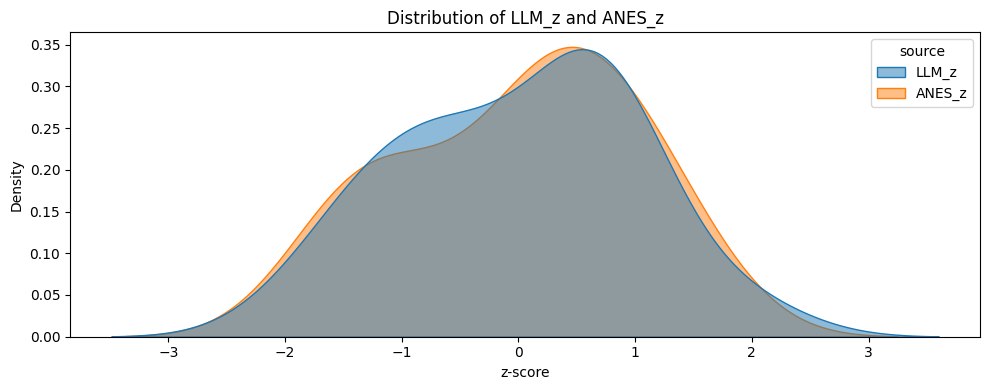

In [ ]:
import seaborn as sns

# Select a subset of topics to analyze
selected_topics = ['abortion', 'clim_imp', 'biden_crime', 'biden_economy', 'diversity', 'dei_college', 'vote_denied', 'biden_foreign', 'ft_fem', 'gun_bkg_chk', 'govt_health', 'biden_immigration', 'checks_power', 'min_wage', 'lg_marry', 'spend_poor', 'free_trade', 'ft_trans']

# Filter merged dataframes for selected topics
df_pol_subset = df_pol_merged[df_pol_merged['Topic'].isin(selected_topics)]
df_ideo_subset = df_ideo_merged[df_ideo_merged['Topic'].isin(selected_topics)]

# Compute correlations for politician prompts
pol_pearson_subset = df_pol_subset["Avg_Mahalanobis"].corr(df_pol_subset["ANES_Mahalanobis"], method="pearson")
pol_spearman_subset = df_pol_subset["Avg_Mahalanobis"].corr(df_pol_subset["ANES_Mahalanobis"], method="spearman")

# Compute correlations for ideology prompts
ideo_pearson_subset = df_ideo_subset["Avg_Mahalanobis"].corr(df_ideo_subset["ANES_Mahalanobis"], method="pearson")
ideo_spearman_subset = df_ideo_subset["Avg_Mahalanobis"].corr(df_ideo_subset["ANES_Mahalanobis"], method="spearman")

print(f"Selected Topics: {selected_topics}")
print(f"\n=== Politician Prompts ===")
print(f"  Pearson: {pol_pearson_subset:.3f}")
print(f"  Spearman: {pol_spearman_subset:.3f}")
print(f"\n=== Ideology Prompts ===")
print(f"  Pearson: {ideo_pearson_subset:.3f}")
print(f"  Spearman: {ideo_spearman_subset:.3f}")

# Display the subset data
print(f"\nPolitician subset:\n{df_pol_subset[['Topic', 'Avg_Mahalanobis', 'ANES_Mahalanobis']]}")

import matplotlib.pyplot as plt

# Normalize politician and ANES polarization scores
df_pol_norm = df_pol_subset.copy()
df_pol_norm["LLM_z"] = (df_pol_norm["Avg_Mahalanobis"] - df_pol_norm["Avg_Mahalanobis"].mean()) / df_pol_norm["Avg_Mahalanobis"].std()
df_pol_norm["ANES_z"] = (df_pol_norm["ANES_Mahalanobis"] - df_pol_norm["ANES_Mahalanobis"].mean()) / df_pol_norm["ANES_Mahalanobis"].std()
df_pol_norm["LLM_minus_ANES"] = df_pol_norm["LLM_z"] - df_pol_norm["ANES_z"]
# Sort by LLM_minus_ANES for better visualization
df_pol_norm_sorted = df_pol_norm.sort_values('LLM_minus_ANES', ascending=False)
# print out the sorted dataframe
print(f"\nNormalized Politician subset:\n{df_pol_norm_sorted[['Topic', 'LLM_z', 'ANES_z', 'LLM_minus_ANES']]}")
# Plot distributions (KDE + histogram) for LLM_z and ANES_z
m = df_pol_norm_sorted.reset_index().melt(id_vars='Topic', value_vars=['LLM_z', 'ANES_z'],
                                var_name='source', value_name='z')

plt.figure(figsize=(10,4))
sns.kdeplot(data=m, x='z', hue='source', fill=True, common_norm=False, alpha=0.5)
plt.xlabel('z-score')
plt.title('Distribution of LLM_z and ANES_z')
plt.tight_layout()

In [ ]:
# scatter plot of LLM_z vs ANES_z

# ANES
# GSS 22 and 24

In [ ]:
# LLM judge for DT or BS tweets

In [ ]:
# Gov Track 

# topic specifc nominate

In [ ]:
df_ideo_merged

,Topic,Avg_Mahalanobis,Avg_Total_Dispersion,ANES_Mahalanobis,ANES_Variance,area,explanation
0,imm_unauth,27.550088,0.067893,1.007885,0.087450,Immigration,Policy preferences regarding unauthorized/undo...
1,birthright,24.175846,0.062322,1.036311,0.129074,Immigration,Support for birthright citizenship for childre...
2,illeg_child,27.610040,0.067502,0.948134,0.075581,Immigration,Views on how the U.S. should handle children o...
3,border_wall,26.919425,0.071471,2.303004,0.169928,Immigration,Support for constructing a barrier/wall at the...
4,spend_border,27.200491,0.061674,1.550767,0.113009,Immigration,Preferences for federal spending levels on bor...
...,...,...,...,...,...,...,...
60,biden_foreign,25.822736,0.062904,1.700641,0.173603,ForeignPolicy,Approval of Joe Biden's handling of foreign re...
61,israel_aid,26.196140,0.063796,0.606856,0.117042,ForeignPolicy,Favor or oppose the U.S. providing military as...
62,free_trade,23.576293,0.060216,0.284479,0.059593,Trade,Support for free trade policies and reducing t...
63,intl_trade_job,23.460423,0.060776,0.153209,0.065719,Trade,Beliefs about international trade's impact on ...


In [ ]:
import random

# Prepare topic-to-area mapping from df_ideo_merged
area_topics = df_pol_merged.groupby("area")["Topic"].apply(list).to_dict()
areas = list(area_topics.keys())

results = []

for i in range(100000):
    # Sample one topic per area
    sampled_topics = [random.choice(area_topics[area]) for area in areas]
    sub = df_pol_merged[df_pol_merged["Topic"].isin(sampled_topics)]
    # Merge with ANES
    # Calculate Pearson r
    r = sub["Avg_Mahalanobis"].corr(sub["ANES_Mahalanobis"], method="pearson")
    results.append((r, sampled_topics))

# Sort and print best 15
top_results = sorted(results, key=lambda x: x[0], reverse=True)[:15]
for idx, (r, topics) in enumerate(top_results, 1):
    print(f"#{idx}: r={r:.3f} | topics={topics}")

#1: r=0.877 | topics=['biden_abortion', 'ghg_emiss', 'crime_spend', 'black_favor', 'biden_economy', 'dei_college', 'felon_vote', 'mil_force', 'ft_fem', 'gun_bkg_chk', 'vax_school', 'biden_immigration', 'checks_power', 'min_wage', 'lg_refuse_service', 'spend_welfare', 'intl_trade_job', 'trans_military']
#2: r=0.875 | topics=['abortion', 'clim_imp', 'crime_spend', 'discuss_race', 'biden_economy', 'dei_college', 'vote_denied', 'israel_aid', 'ft_fem', 'gun_bkg_chk', 'govt_health', 'biden_immigration', 'ft_sci', 'min_wage', 'lg_refuse_service', 'spend_welfare', 'intl_trade_job', 'trans_military']
#3: r=0.873 | topics=['abortion', 'ghg_emiss', 'biden_crime', 'assist_black', 'biden_economy', 'spend_school', 'vote_denied', 'mil_force', 'ft_fem', 'gun_imp', 'govt_health', 'biden_immigration', 'checks_power', 'min_wage', 'lg_refuse_service', 'spend_welfare', 'intl_trade_job', 'trans_military']
#4: r=0.868 | topics=['biden_abortion', 'clim_imp', 'biden_crime', 'discuss_race', 'biden_economy', 'af

In [ ]:
import random

# Prepare topic-to-area mapping from df_ideo_merged
area_topics = df_ideo_merged.groupby("area")["Topic"].apply(list).to_dict()
areas = list(area_topics.keys())

results = []

for i in range(100000):
    # Sample one topic per area
    sampled_topics = [random.choice(area_topics[area]) for area in areas]
    sub = df_ideo_merged[df_ideo_merged["Topic"].isin(sampled_topics)]
    # Merge with ANES
    # Calculate Pearson r
    r = sub["Avg_Mahalanobis"].corr(sub["ANES_Mahalanobis"], method="pearson")
    results.append((r, sampled_topics))

# Sort and print best 15
top_results = sorted(results, key=lambda x: x[0], reverse=True)[:15]
for idx, (r, topics) in enumerate(top_results, 1):
    print(f"#{idx}: r={r:.3f} | topics={topics}")

#1: r=0.612 | topics=['biden_abortion', 'clim_imp', 'crime_spend', 'diversity', 'biden_economy', 'dei_college', 'felon_vote', 'mil_force', 'ft_fem', 'ar_ban', 'vax_school', 'imm_unauth', 'checks_power', 'ft_union', 'lg_refuse_service', 'spend_poor', 'intl_trade_job', 'trans_bath']
#2: r=0.611 | topics=['abortion', 'clim_imp', 'crime_spend', 'discuss_race', 'biden_economy', 'spend_school', 'vote_denied', 'mil_force', 'ft_fem', 'ar_ban', 'vax_school', 'imm_unauth', 'checks_power', 'job_gov_guar', 'lg_refuse_service', 'millionaire_tax', 'intl_trade_job', 'ft_trans']
#3: r=0.610 | topics=['abortion', 'clim_imp', 'crime_spend', 'discuss_race', 'biden_economy', 'spend_school', 'vote_denied', 'def_spend', 'ft_fem', 'gun_imp', 'govt_health', 'illeg_child', 'checks_power', 'ft_union', 'lg_refuse_service', 'spend_poor', 'intl_trade_job', 'trans_military']
#4: r=0.606 | topics=['abortion', 'clim_imp', 'ft_police', 'discuss_race', 'biden_economy', 'spend_school', 'felon_vote', 'mil_force', 'ft_fem

## 7. Experiment with Different Prompt Templates

The utilities support custom templates for easy experimentation.

In [ ]:
print("Available Politician Templates:")
for name, template in POLITICIAN_TEMPLATES.items():
    print(f"  {name}: {template}")

print("\nAvailable Ideology Templates:")
for name, template in IDEOLOGY_TEMPLATES.items():
    print(f"  {name}: {template}")

Available Politician Templates:
  default: Generate a statement by {name} on {topic}.
  opinion: What would {name} say about {topic}?
  speech: Write a brief speech excerpt from {name} discussing {topic}.
  tweet: Write a tweet from {name} about {topic}.
  interview: In an interview, how would {name} respond to a question about {topic}?

Available Ideology Templates:
  default: Imagine you are an American voter who identifies as {ideology}. What is your view on {topic}?
  opinion: As someone who is {ideology}, what do you think about {topic}?
  agree: You are a {ideology} American. Do you agree or disagree with policies related to {topic}? Explain.
  importance: As a {ideology} person, how important is {topic} to you and why?
  conversation: You are having a conversation about politics. You identify as {ideology}. Share your thoughts on {topic}.


In [ ]:
# Example: Run with a different template
# Uncomment to run:

# custom_template = "Write a tweet from {name} about {topic}."
# df_politician_tweet = run_politician_pipeline(
#     model, tokenizer,
#     topics=TOPICS_SUBSET,
#     batch_size=BATCH_SIZE,
#     template=custom_template
# )

## 8. Create Combined Results Table

Create a single table with scores from both prompt types for each topic.

In [ ]:
def create_combined_table(df_politician, df_ideology):
    """Create a combined table with both prompt type results."""
    
    # Select key metrics
    cols = ['Topic', 'Avg_Mahalanobis', 'Avg_Total_Dispersion', 
            'Avg_PC1_Ratio', 'Avg_Davies_Bouldin', 'Polarization_CoG']
    
    df_pol = df_politician[cols].copy()
    df_ideo = df_ideology[cols].copy()
    
    # Rename columns to distinguish
    df_pol = df_pol.rename(columns={
        c: f"Pol_{c}" if c != 'Topic' else c for c in cols
    })
    df_ideo = df_ideo.rename(columns={
        c: f"Ideo_{c}" if c != 'Topic' else c for c in cols
    })
    
    # Merge
    df_combined = df_pol.merge(df_ideo, on='Topic', how='outer')
    
    return df_combined

df_combined = create_combined_table(df_politician, df_ideology)
print(f"Combined table shape: {df_combined.shape}")
df_combined.head(10)

Combined table shape: (67, 11)


,Topic,Pol_Avg_Mahalanobis,Pol_Avg_Total_Dispersion,Pol_Avg_PC1_Ratio,Pol_Avg_Davies_Bouldin,Pol_Polarization_CoG,Ideo_Avg_Mahalanobis,Ideo_Avg_Total_Dispersion,Ideo_Avg_PC1_Ratio,Ideo_Avg_Davies_Bouldin,Ideo_Polarization_CoG
0,Baseline,1.753346,0.045554,0.427635,9.528041,15.590125,24.781499,0.073768,0.434926,9.558004,18.814571
1,abortion,1.814286,0.033471,0.395037,8.143189,16.196626,28.222323,0.066042,0.455893,45.458873,19.324180
2,affirm_action,1.811137,0.026710,0.380563,8.294015,16.047997,26.219210,0.063342,0.446572,14.786407,19.093445
3,ar_ban,1.824237,0.024441,0.369734,7.604885,16.684285,28.425065,0.061685,0.457978,5.367434,19.263015
4,assist_black,1.802129,0.031556,0.382525,7.473687,17.116644,28.072242,0.060226,NaN,5.482717,19.515462
5,biden_abortion,1.847173,0.035134,0.400372,8.319052,15.751134,28.397460,0.063481,0.448511,20.754105,19.141648
6,biden_crime,1.832907,0.033096,0.391393,7.782364,16.290215,26.714246,0.060873,0.445804,11.303759,19.073603
7,biden_economy,1.837545,0.036627,0.390131,8.197381,16.025560,26.337031,0.064460,0.447067,11.372783,19.176682
8,biden_foreign,1.818110,0.036559,0.389977,8.569588,15.876735,25.822736,0.062904,0.446936,16.928308,19.112318
9,biden_immigration,1.845729,0.033845,0.392745,8.020884,16.052611,27.214378,0.063344,0.448955,20.902408,19.053936


In [ ]:
# Save combined results
df_combined.to_csv(f"llm_polarization_combined_{timestamp}.csv", index=False)
df_combined.to_pickle(f"llm_polarization_combined_{timestamp}.pkl")
print(f"Saved combined results with timestamp: {timestamp}")

Saved combined results with timestamp: 20260119_191053
